# Customer Analytics — Level 6: Customer Behavior Analysis

After identifying customer value (CLV) and segmenting customers using RFM Analysis, the next step is to understand **how customers behave throughout their purchasing journey**.

Behavioral analytics focuses on purchasing patterns rather than customer value alone. Understanding when customers buy, how frequently they return, and the size of their typical orders enables businesses to design more effective marketing campaigns, improve customer engagement, and optimize promotional timing.

This notebook explores customer purchasing behavior through four perspectives:

- Order Interval Analysis
- Basket Size Analysis
- Revenue per Order
- Purchase Timing Patterns

Together, these analyses provide actionable insights for campaign planning, inventory management, and customer engagement strategies.

Data source: `online_retail_clean.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

sns.set_theme(style="whitegrid", palette="deep")
sns.set_context("talk")

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns',None)

df = pd.read_csv("data/raw/online_retail_clean.csv", parse_dates=["InvoiceDate"])
print(f"Total transaksi: {len(df):,} | Total order: {df['InvoiceNo'].nunique():,} | Total customer: {df['CustomerID'].nunique():,}")

Total transaksi: 397,884 | Total order: 18,532 | Total customer: 4,338


## 1. Order Interval Analysis

One of the most useful behavioral metrics is the average time between consecutive purchases.

For customers who have placed multiple orders, we calculate the average number of days between transactions. Understanding this purchasing rhythm helps businesses estimate when customers are most likely to return and identify the optimal timing for reminder emails, promotional campaigns, or replenishment offers.

In [2]:
order_dates = df.groupby(["CustomerID","InvoiceNo"])["InvoiceDate"].first().reset_index()
order_dates = order_dates.sort_values(["CustomerID","InvoiceDate"])
order_dates["PrevDate"] = order_dates.groupby("CustomerID")["InvoiceDate"].shift(1)
order_dates["DaysSincePrev"] = (order_dates["InvoiceDate"] - order_dates["PrevDate"]).dt.days

intervals = order_dates["DaysSincePrev"].dropna()
print(f"Customer  with interval data (>=2 order)  : {order_dates['CustomerID'].nunique() - (order_dates.groupby('CustomerID').size()==1).sum():,}")
print(f"Average interval between order            : {intervals.mean():.1f} days")
print(f"Median interval between order             : {intervals.median():.1f} days")
print(f"P25 / P75                                 : {intervals.quantile(0.25):.0f} / {intervals.quantile(0.75):.0f} days")

Customer  with interval data (>=2 order)  : 2,845
Average interval between order            : 39.5 days
Median interval between order             : 21.0 days
P25 / P75                                 : 6 / 51 days


### Distribution of Purchase Intervals

The distribution below illustrates how frequently customers return to make another purchase.

Rather than relying solely on an average value, the full distribution reveals whether purchasing behavior is relatively consistent or varies substantially across the customer base.

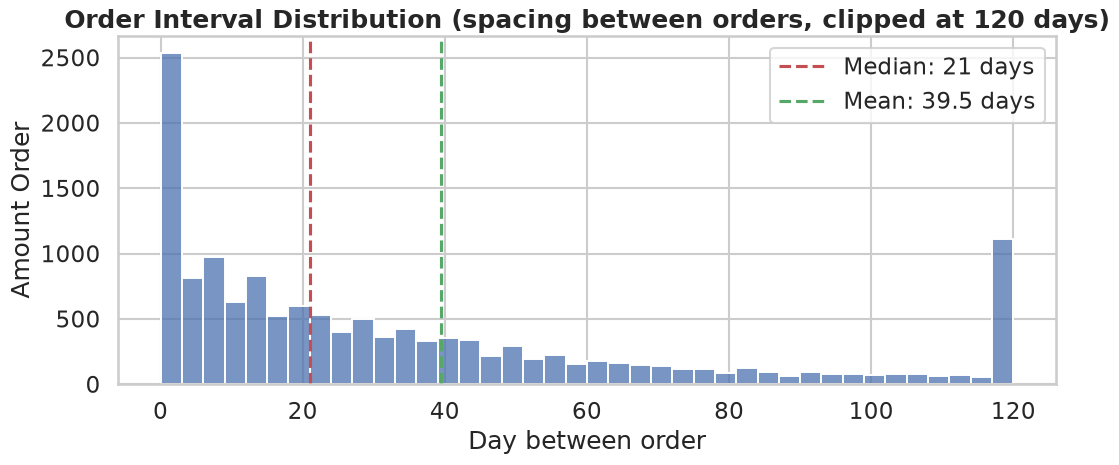

59.6% repeat orders occur within 30 days from the previous order.


In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
clipped_intervals = intervals.clip(upper=120)
sns.histplot(clipped_intervals, bins=40, color="#4C72B0", ax=ax)
ax.axvline(intervals.median(), color="#C44E52", linestyle="--", label=f"Median: {intervals.median():.0f} days")
ax.axvline(intervals.mean(), color="#55A868", linestyle="--", label=f"Mean: {intervals.mean():.1f} days")
ax.set_title("Order Interval Distribution (spacing between orders, clipped at 120 days)")
ax.set_xlabel("Day between order")
ax.set_ylabel("Amount Order")
ax.legend()
plt.tight_layout()
plt.savefig("pictures/level6_order_interval_dist.png", dpi=120, bbox_inches='tight')
plt.show()

pct_within_30days = (intervals <= 30).mean() * 100
print(f"{pct_within_30days:.1f}% repeat orders occur within 30 days from the previous order.")

## 2. Basket Size Analysis

Basket size measures how many unique products customers purchase within a single order.

This metric provides insight into purchasing behavior and product bundling opportunities. Larger baskets may indicate successful cross-selling, while smaller baskets can reveal opportunities to encourage customers to purchase additional products.

In [4]:
basket = df.groupby("InvoiceNo").agg(
    NumLineItems=("StockCode","nunique"),
    TotalQty=("Quantity","sum"),
    Revenue=("Revenue","sum")
).reset_index()

print("Basket size (amount type products by orders):")
print(basket["NumLineItems"].describe().round(1))
print(f"\nAverege quantity of goods by orders: {basket['TotalQty'].mean():.1f} pcs")

Basket size (amount type products by orders):
count   18,532.00
mean        20.90
std         23.80
min          1.00
25%          6.00
50%         15.00
75%         27.00
max        541.00
Name: NumLineItems, dtype: float64

Averege quantity of goods by orders: 278.9 pcs


### Distribution of Basket Sizes

The following visualization shows how many unique products customers typically purchase in each transaction.

Analyzing the distribution helps identify common purchasing patterns and reveals whether customers generally place focused orders or purchase a broader range of products.

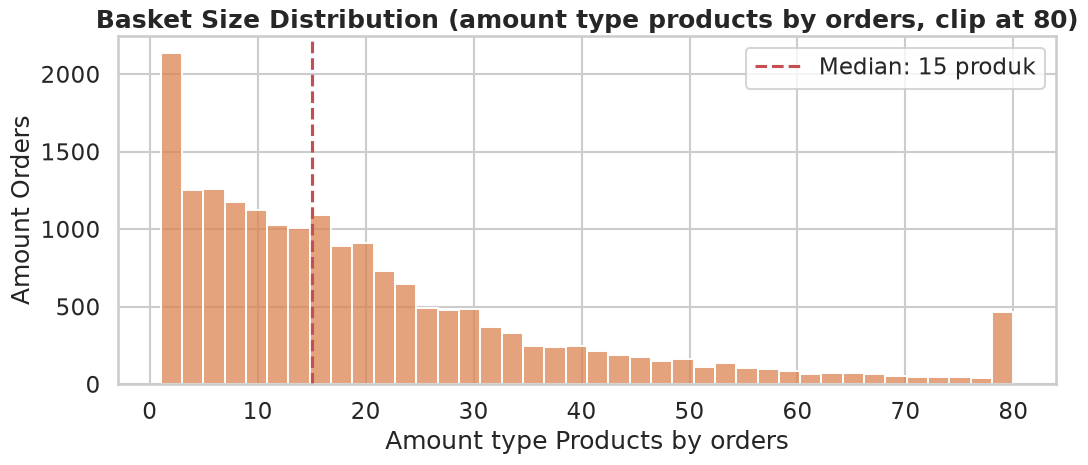

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(basket["NumLineItems"].clip(upper=80), bins=40, color="#DD8452", ax=ax)
ax.axvline(basket["NumLineItems"].median(), color="#C44E52", linestyle="--",
           label=f"Median: {basket['NumLineItems'].median():.0f} produk")
ax.set_title("Basket Size Distribution (amount type products by orders, clip at 80)")
ax.set_xlabel("Amount type Products by orders")
ax.set_ylabel("Amount Orders")
ax.legend()
plt.tight_layout()
plt.savefig("pictures/level6_basket_size_dist.png", dpi=120, bbox_inches='tight')
plt.show()

## 3. Revenue per Order Analysis

Order frequency alone does not fully explain customer value. It is equally important to understand how much revenue customers generate in each transaction.

Revenue per order provides insight into purchasing intensity and helps distinguish customers who purchase frequently from those who generate high value through fewer but larger transactions.

Revenue per Order (AOV)  : £480.87
Median Revenue per Order  : £303.04


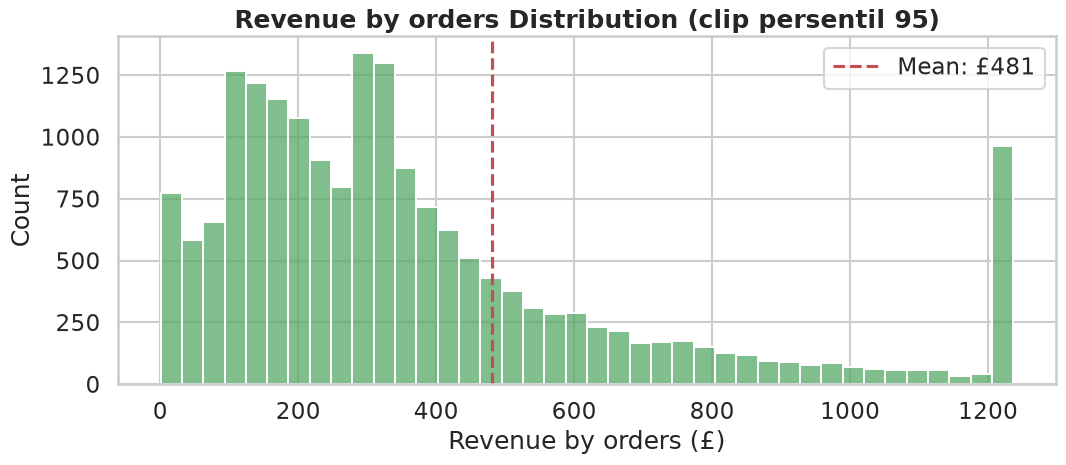

In [6]:
print(f"Revenue per Order (AOV)  : £{basket['Revenue'].mean():,.2f}")
print(f"Median Revenue per Order  : £{basket['Revenue'].median():,.2f}")

fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(basket["Revenue"].clip(upper=basket["Revenue"].quantile(0.95)), bins=40, color="#55A868", ax=ax)
ax.axvline(basket["Revenue"].mean(), color="#C44E52", linestyle="--", label=f"Mean: £{basket['Revenue'].mean():,.0f}")
ax.set_title("Revenue by orders Distribution (clip persentil 95)")
ax.set_xlabel("Revenue by orders (£)")
ax.legend()
plt.tight_layout()
plt.savefig("pictures/level6_revenue_per_order_dist.png", dpi=120, bbox_inches='tight')
plt.show()

## 4. Purchase Timing Analysis

Customer purchasing behavior often varies across different time periods.

In this section, we analyze transaction patterns by month, weekday, and hour to identify periods of higher customer activity. Understanding these temporal trends supports more effective campaign scheduling, staffing decisions, and inventory planning.

In [7]:
df["MonthName"] = df["InvoiceDate"].dt.month_name()
df["MonthNum"] = df["InvoiceDate"].dt.month
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"] = df["InvoiceDate"].dt.hour

season_map = {12:"Winter",1:"Winter",2:"Winter", 3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer", 9:"Autumn",10:"Autumn",11:"Autumn"}
df["Season"] = df["MonthNum"].map(season_map)

rev_by_month = df.groupby("MonthName")["Revenue"].sum().sort_values(ascending=False)
rev_by_dow = df.groupby("DayOfWeek")["Revenue"].sum().sort_values(ascending=False)
rev_by_season = df.groupby("Season")["Revenue"].sum().sort_values(ascending=False)

print("Revenue by Month (top 5):")
print(rev_by_month.head())
print("\nRevenue by Day of Week:")
print(rev_by_dow)
print("\nRevenue by Season:")
print(rev_by_season)

print(f"\nNote: there are no transactions at all on Saturdays in this dataset -- the store is likely closed on Saturdays.")
print(f"Best month    : {rev_by_month.index[0]}")
print(f"Best day      : {rev_by_dow.index[0]}")
print(f"Best season   : {rev_by_season.index[0]}")

Revenue by Month (top 5):
MonthName
November    1,161,817.38
December    1,090,906.68
October     1,039,318.79
September     952,838.38
May           678,594.56
Name: Revenue, dtype: float64

Revenue by Day of Week:
DayOfWeek
Thursday    1,976,859.07
Tuesday     1,700,634.63
Wednesday   1,588,336.17
Friday      1,485,917.40
Monday      1,367,146.41
Sunday        792,514.22
Name: Revenue, dtype: float64

Revenue by Season:
Season
Autumn   3,153,974.55
Winter   2,107,489.07
Summer   1,906,648.60
Spring   1,743,295.68
Name: Revenue, dtype: float64

Note: there are no transactions at all on Saturdays in this dataset -- the store is likely closed on Saturdays.
Best month    : November
Best day      : Thursday
Best season   : Autumn


### Customer Activity Heatmap

The heatmap below visualizes purchasing activity across different days of the week and hours of the day.

This view highlights peak shopping periods and helps identify when customers are most engaged, providing valuable guidance for marketing campaigns and operational planning.

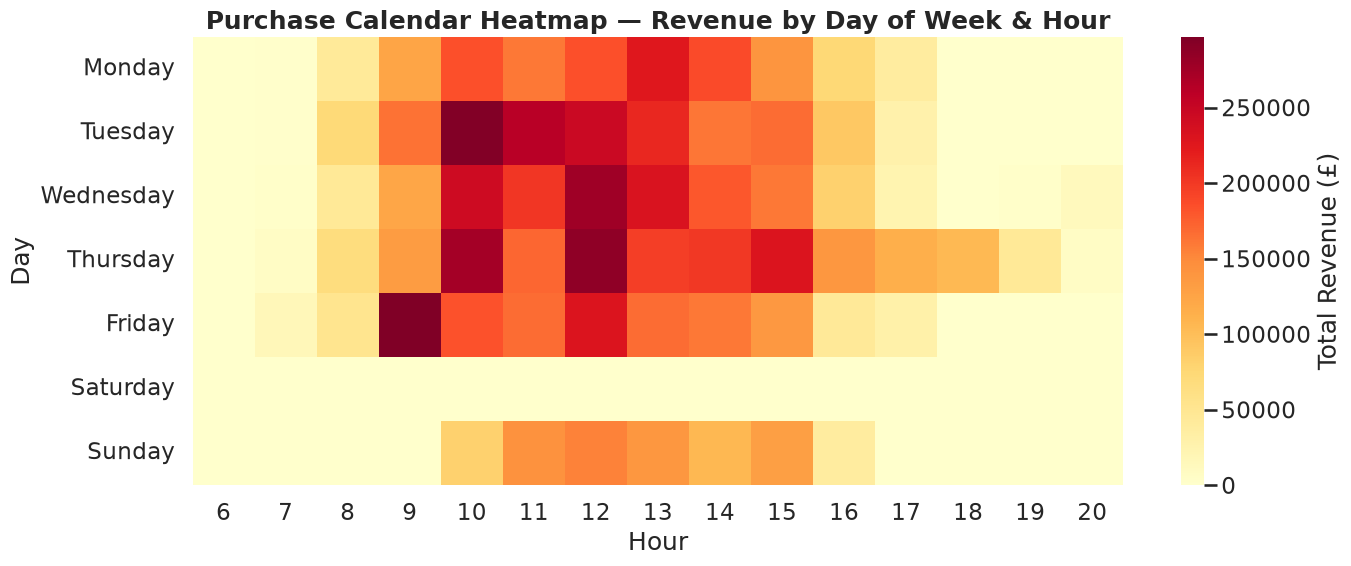

In [8]:
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
calendar_data = df.groupby(["DayOfWeek","Hour"])["Revenue"].sum().reset_index()
calendar_pivot = calendar_data.pivot(index="DayOfWeek", columns="Hour", values="Revenue").reindex(dow_order)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(calendar_pivot.fillna(0), cmap="YlOrRd", ax=ax, cbar_kws={'label':'Total Revenue (£)'})
ax.set_title("Purchase Calendar Heatmap — Revenue by Day of Week & Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Day")
plt.tight_layout()
plt.savefig("pictures/level6_purchase_calendar_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()

**Visual: Revenue by Month & Season**

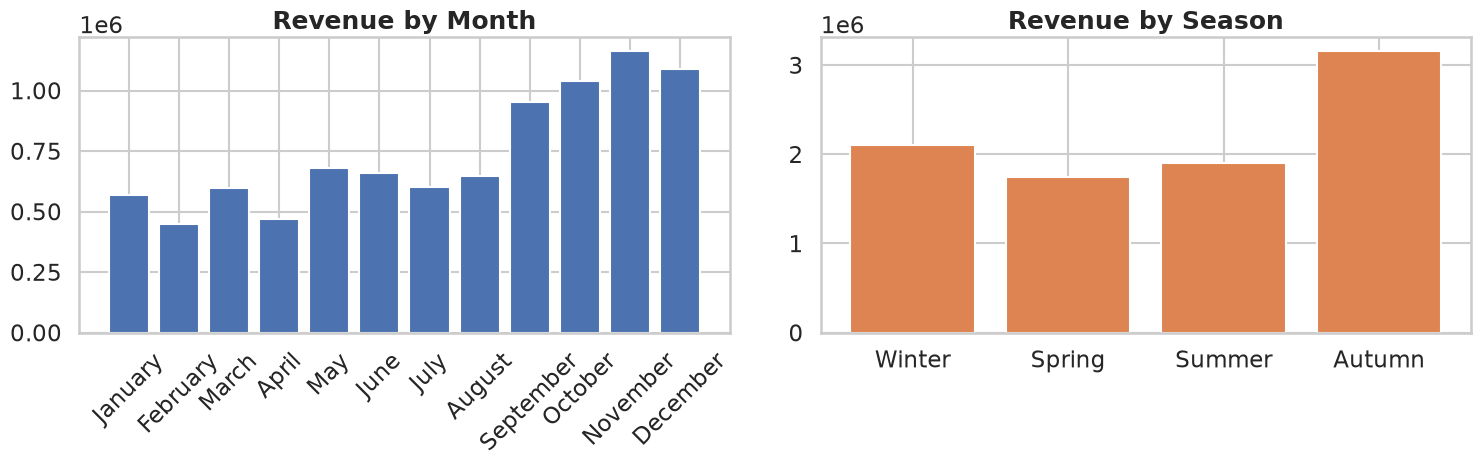

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

month_order = ["January","February","March","April","May","June","July","August","September","October","November","December"]
rev_by_month_ordered = df.groupby("MonthName")["Revenue"].sum().reindex(month_order)
axes[0].bar(rev_by_month_ordered.index, rev_by_month_ordered.values, color="#4C72B0")
axes[0].set_title("Revenue by Month")
axes[0].tick_params(axis='x', rotation=45)

season_order = ["Winter","Spring","Summer","Autumn"]
rev_by_season_ordered = df.groupby("Season")["Revenue"].sum().reindex(season_order)
axes[1].bar(rev_by_season_ordered.index, rev_by_season_ordered.values, color="#DD8452")
axes[1].set_title("Revenue by Season")

plt.tight_layout()
plt.savefig("pictures/level6_revenue_month_season.png", dpi=120, bbox_inches='tight')
plt.show()

In [10]:
import os

os.makedirs("data/processed", exist_ok = True)
order_dates.to_csv("data/processed/customer_order_intervals.csv", index=False)
basket.to_csv("data/processed/order_basket_size.csv", index=False)

## 5. Executive Summary

Customer behavior analysis provides a deeper understanding of how customers interact with the business beyond traditional revenue metrics.

Order interval analysis reveals the typical purchasing rhythm of repeat customers, providing guidance for campaign timing and customer re-engagement efforts. Basket size analysis highlights purchasing patterns within individual transactions and identifies opportunities for cross-selling and product bundling.

Revenue-per-order analysis complements frequency metrics by distinguishing customers who generate value through larger transactions from those who contribute through frequent purchases. Finally, purchase timing analysis uncovers seasonal and temporal shopping patterns that can support promotional planning and operational decision-making.

Together, these behavioral insights transform transaction data into actionable recommendations that help businesses improve customer engagement, increase order value, and optimize marketing performance.

### Next Steps

The final notebook in this Customer Analytics series will combine all previous analyses into a unified Business Recommendation Engine, translating analytical findings into practical business strategies and executive-level recommendations.